#Answer Q1#

FUNCTIONS

In [2]:

import numpy as  np
from math import exp, sqrt
import matplotlib.pyplot as plt   
from scipy.stats import norm 



def basketSimulation( T, S10, S20, u, N, volatility, rho, weigths : list[float]):
    
    # Geometric Motion 
    # The dynamic for the 2 stocks : dSt = St( u.dt + volatility.dWt )
    # Generate gaussian number used to simulate the brownian motion dWt = sqrt(dt) * Z
    #
    
    #Init parameters & vectors
    dt = T / N
    S1 = np.zeros(N + 1)
    S2 = np.zeros(N + 1)
    basket = np.zeros( N + 1)
    
    S1[0] = S10
    S2[0] = S20
    basket[0] = weigths[0]*S1[0] + weigths[1]*S2[0]
    #--- End -- init
    
    #dWi
    dW1 = np.random.normal(0, np.sqrt(dt), N)
    dW2 = np.random.normal(0, np.sqrt(dt), N)
    
    # Initialize arrays for stock prices and basket
    for i in range(1, N+1):
        
        S1[i] = S1[i-1] * np.exp((u - 0.5 * volatility**2) * dt + volatility * dW1[i-1])
        S2[i] = S2[i-1] * np.exp((u - 0.5 * volatility**2) * dt + volatility * (rho * dW1[i-1] + np.sqrt(1 - rho**2) * dW2[i-1] )) #Using Cholesky
            
        basket[i] = weigths[0]*S1[i] + weigths[1]*S2[i]
    
    return S1, S2, np.linspace(0, T, N+1), basket

#------------------ AUX---------------------

def callPriceBS ( B, r, T, K, volatility, rho):
    # On a simple stock we've => price = S.N(d1) -K exp(-rT).N(d2)
    # the solution of this GBM : S0.exp(-r.T)
    # We'll replace S by B : basket price which's: (S1 + S2)/2 = B
    
    #volatility_Basket & Spot
    Spot = B[0]
    volatility1 = volatility2 = volatility
    volatilityB = np.sqrt( ((0.5 * volatility1)**2 + (0.5 * volatility2)** 2 + 2 * 0.5 * 0.5 * rho * volatility1 * volatility2))
    
    #d1 & d2
    d1 = float((np.log(Spot/K) + (r + (volatilityB **2)/2)* T)/(volatilityB * np.sqrt(T)))
    d2 = d1 - volatilityB * np.sqrt(T)

    return  float(Spot*norm.cdf(d1) - K * exp(-r*T )*norm.cdf(d2)) 

#---------------------------------------------------
def callPriceMonteCarlo ( K, M, T, S10,  S20, r, N, volatility, rho, weigths):
    # Call price MonteCarlo Simulation
    # M number of simulation
    
    payoffs = np.zeros(M)
    
    for i in range(M):
      _, _, _, basket  = basketSimulation( T, S10,  S20, r, N, volatility, rho, weigths)
      payoffs[i]= max(basket[-1] - K, 0)
    
    callPrice = np.exp(-r*T)*np.mean(payoffs)
    return callPrice
      

INIT_PARAMETERS

In [3]:
#Init_Param :
############
T = 2 # 2 years
S10 = 100 # Stock 1 spot at t =0
S20 = 111 # Stock 1 spot at t =0
u = 0.02 #drift
N = 1000 # number of points
M = 10000  # Number of Monte-Carlo simulations
volatility = 0.2 #volatilityatility
rho = 0.2 #correlation coef
weigths =  [0.5, 0.5]
riskFreeRate = 0.03
strike = 95

Calling the functions

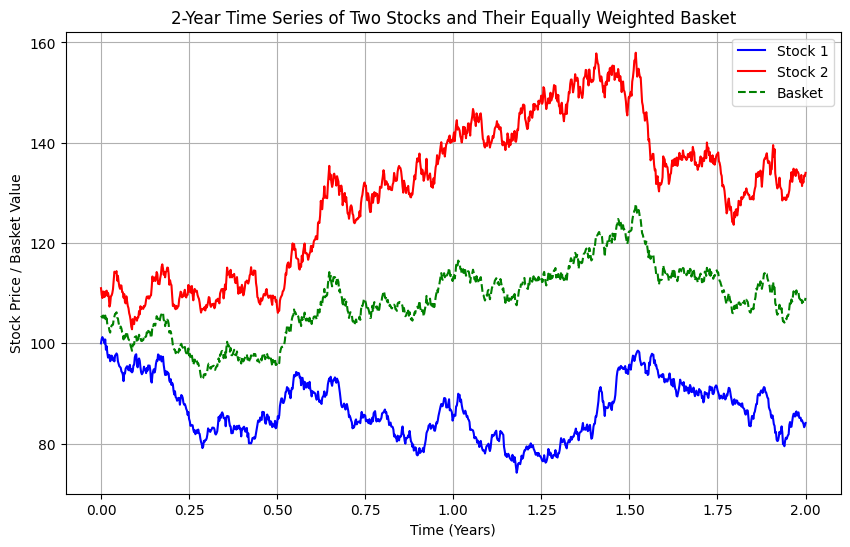

In [4]:
S1, S2, time, basket = basketSimulation( T, S10,  S20, u, N, volatility, rho, weigths)

plt.figure(figsize=(10, 6))
plt.plot(time, S1, label="Stock 1", color='blue')
plt.plot(time, S2, label="Stock 2", color='red')
plt.plot(time, basket, label="Basket", color='green', linestyle='dashed')
plt.title("2-Year Time Series of Two Stocks and Their Equally Weighted Basket")
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price / Basket Value")
plt.legend()
plt.grid(True)
plt.show()  

In [5]:
price = callPriceBS ( basket, riskFreeRate, T, strike, volatility, rho)
price

18.80329570664162

In [6]:
price = callPriceMonteCarlo ( strike, M, T, S10,  S20, riskFreeRate, N, volatility, rho, weigths)
price

18.731582612865672

The two results are close, but the Monte-Carlo result have some simulation error due to the finite number of paths. Increasing 
M will reduce this error ( 100 -> error : 2.2 | 1000 -> 0.34)

#Answer Q2#

FUNCTIONS

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta



# Holidays (1st Jan, 25th Dec, 26th Dec)
HOLIDAYS = [
    datetime(2023, 1, 1), datetime(2023, 12, 25), datetime(2023, 12, 26),
    datetime(2024, 1, 1), datetime(2024, 12, 25), datetime(2024, 12, 26)
]

# Function to adjust dates for business days (modified following convention)
def adjustForBusinessDay(date):
    while date in HOLIDAYS or date.weekday() >= 5:  # Weekend or holiday
        date += timedelta(days=1)
    return date


# Function to calculate the payoff
def calculatePayoff(basketTrajectory, notional, couponDates, couponRate, additionalCouponRate, daysInYear ):
    payoffs = []
    for path in basketTrajectory:
        # Check basket value 10 business days before maturity
        basketAtMaturity = path[-10]
        if basketAtMaturity >= 80:
            payoff = notional
        else:
            payoff = notional * (basketAtMaturity / 80)
        
        # Add fixed and additional coupons
        for couponDate in couponDates:
            basketAtCpn = path[couponDate - 10]  # 5 business days before coupon date
            if basketAtCpn > 100:
                payoff += notional * (couponRate + additionalCouponRate) * (90 / daysInYear)
            else:
                payoff += notional * couponRate * (90 / daysInYear)
        
        payoffs.append(payoff)
    return np.array(payoffs)


INIT_PARAMETERS

In [8]:
notional = 100  
couponRate = 0.02  
additionalCouponRate = 0.04  # 4% p.a. additional coupon
matu = 2  # 2 years
M = 10000  # Number of Monte-Carlo simulations
daysInYear = 360  # ACT/360 day count convention
businessDaysPerYear = 252  # Business days in a year
volatility = 0.2  # Assumed volatility of the basket
riskFreeRate = 0.01  # Assumed risk-free rate
intitialBasketValue = 100  # Initial basket value
couponDates = [90, 180, 270, 360, 450, 540, 630, 720]  # Quarterly coupon dates in days

Calling the functions

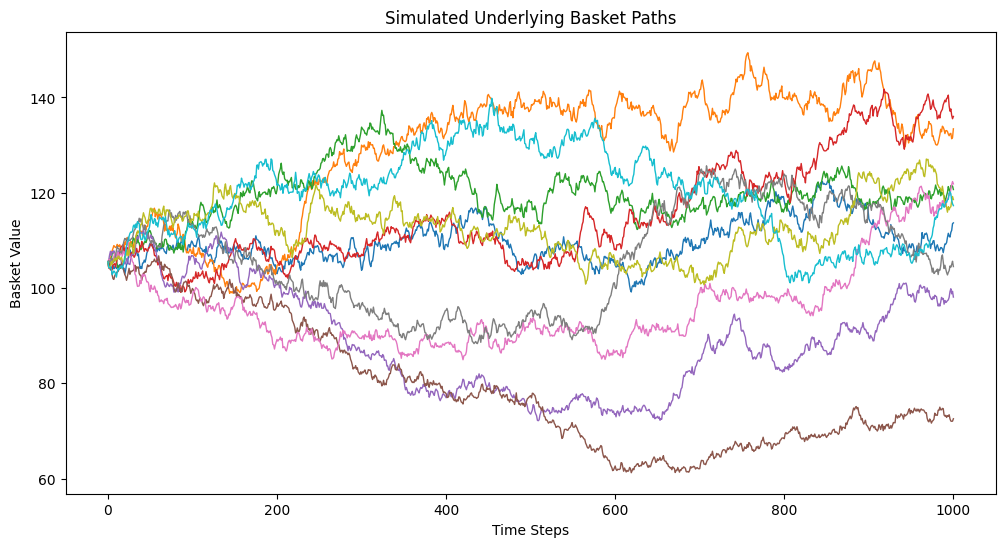

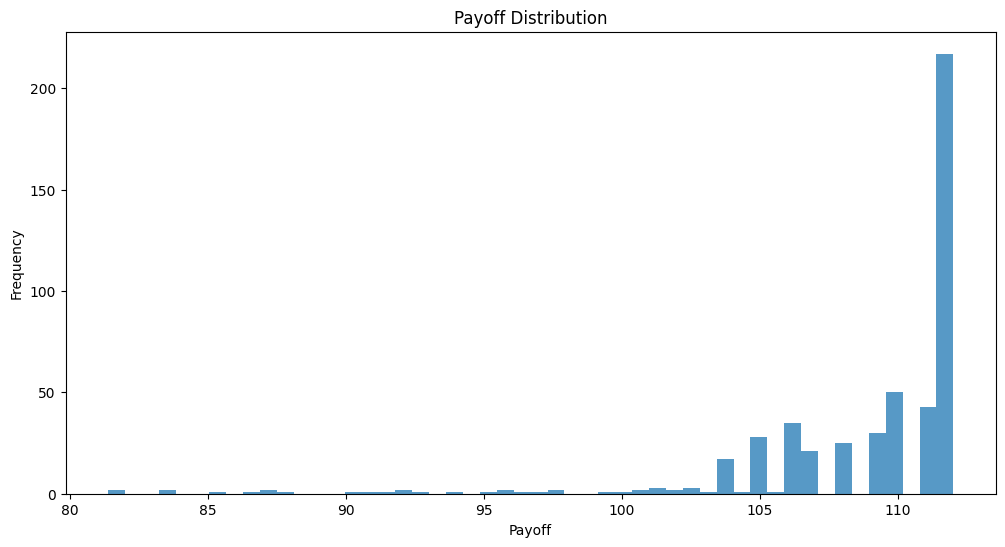

Estimated Payoff: 108.78


In [9]:
# Simulate basket paths
M = matu * businessDaysPerYear

basketTrajectory = np.zeros((M, N + 1))


for i in range(M):
    
    _, _, _, basket = basketSimulation( T, S10,  S20, u, N, volatility, rho, weigths)
    basketTrajectory[i] = basket

# Calculate payoffs
payoffs = calculatePayoff(basketTrajectory, notional, couponDates, couponRate, additionalCouponRate, daysInYear)

# Plot simulated underlying paths
plt.figure(figsize=(12, 6))
for i in range(10):  # Plot first 10 paths for visualization
    plt.plot(basketTrajectory[i], lw=1)
plt.title("Simulated Underlying Basket Paths")
plt.xlabel("Time Steps")
plt.ylabel("Basket Value")
plt.show()

# Plot payoff distribution
plt.figure(figsize=(12, 6))
plt.hist(payoffs, bins=50, alpha=0.75)
plt.title("Payoff Distribution")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.show()

# Print average payoff
print(f"Estimated Payoff: {np.mean(payoffs):.2f}")

We conclude that the price of our product will be : ( payoffs discounted)

In [10]:
estimatedPayoff = np.mean(payoffs)
estimatedPrice = np.exp(-riskFreeRate * 2) * estimatedPayoff
estimatedPrice

106.62389152737701